<a href="https://colab.research.google.com/github/Saint-Sakaro/ML_practice_Belov_Fedor/blob/main/sem_1_lineal_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [154]:
# https://drive.google.com/file/d/1-Jd-dwLgVxcXOPTd9oJyqeFddLmRYeWX/view?usp=sharing
!gdown '1-Jd-dwLgVxcXOPTd9oJyqeFddLmRYeWX'

Downloading...
From: https://drive.google.com/uc?id=1-Jd-dwLgVxcXOPTd9oJyqeFddLmRYeWX
To: /content/delivery_dataset.csv
100% 23.2k/23.2k [00:00<00:00, 30.1MB/s]


In [155]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [156]:
data = pd.read_csv('/content/delivery_dataset.csv')
data

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


In [157]:
data['Шифр заказа (ID)'].value_counts(dropna=False), data['Дата заказа (ГГГГ-ММ-ДД)'].value_counts(dropna=False), data['Дата заказа (ГГГГ-ММ-ДД)'].describe()

(Шифр заказа (ID)
 ORD-202608500    1
 ORD-202608001    1
 ORD-202608002    1
 ORD-202608003    1
 ORD-202608484    1
                 ..
 ORD-202608009    1
 ORD-202608008    1
 ORD-202608007    1
 ORD-202608006    1
 ORD-202608005    1
 Name: count, Length: 500, dtype: int64,
 Дата заказа (ГГГГ-ММ-ДД)
 2026-09-02    22
 2026-09-04    21
 2026-08-24    19
 2026-09-01    19
 2026-08-26    18
 2026-09-08    16
 2026-09-06    16
 2026-08-28    16
 2026-08-02    16
 2026-08-25    15
 2026-08-23    15
 2026-08-12    15
 2026-08-01    14
 2026-08-29    14
 2026-09-05    14
 2026-08-22    14
 2026-08-16    14
 2026-08-08    13
 2026-08-03    13
 2026-09-09    12
 2026-08-09    12
 2026-08-30    12
 2026-08-07    11
 2026-08-19    11
 2026-08-05    11
 2026-08-14    10
 2026-08-15    10
 2026-08-17    10
 2026-08-20    10
 2026-08-04    10
 2026-08-11     9
 2026-08-21     9
 2026-08-06     9
 2026-08-27     9
 2026-09-03     8
 2026-08-18     8
 2026-08-13     8
 2026-08-31     6
 2026-08-10

<Axes: >

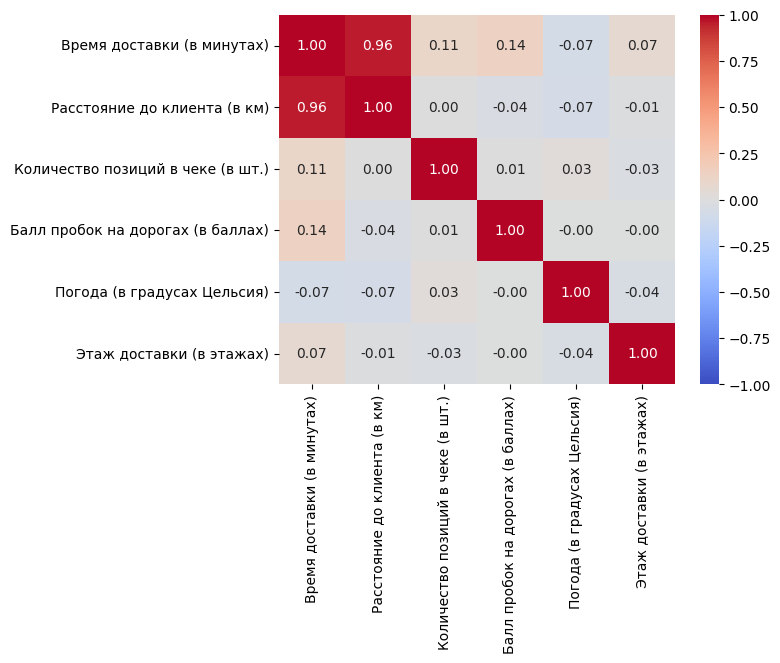

In [158]:
cols = ['Время доставки (в минутах)', 'Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)',	'Балл пробок на дорогах (в баллах)',	'Погода (в градусах Цельсия)',	'Этаж доставки (в этажах)']
corr = data[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)

In [159]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Расстояние до клиента (в км),500.0,6.8296,5.772307,0.3,2.100,5.50,9.800,23.9
Количество позиций в чеке (в шт.),500.0,4.1560,3.230563,1.0,2.000,3.00,5.000,16.0
Балл пробок на дорогах (в баллах),500.0,4.6380,2.248793,1.0,3.000,5.00,6.000,10.0
Погода (в градусах Цельсия),500.0,17.6988,5.774552,8.0,13.375,17.50,22.525,28.0
Этаж доставки (в этажах),500.0,7.8080,6.045845,1.0,3.000,6.00,11.000,25.0
Время доставки (в минутах),500.0,42.1304,26.497412,9.0,22.075,34.55,53.400,135.0


In [160]:
data.nunique()

,0
Дата заказа (ГГГГ-ММ-ДД),40
Шифр заказа (ID),500
Расстояние до клиента (в км),162
Количество позиций в чеке (в шт.),16
Балл пробок на дорогах (в баллах),10
Погода (в градусах Цельсия),185
Этаж доставки (в этажах),25
Время доставки (в минутах),368


In [161]:
data['dow'] = pd.to_datetime(data['Дата заказа (ГГГГ-ММ-ДД)']).dt.dayofweek
data.groupby('dow')['Время доставки (в минутах)'].mean()


,Время доставки (в минутах)
dow,
0,39.128814
1,40.312987
2,42.060674
3,47.952273
4,46.649254
5,38.548101
6,42.687059


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих;
* в тестовой: 100 последних.

In [162]:
data = data.drop(columns=['Дата заказа (ГГГГ-ММ-ДД)', 'Шифр заказа (ID)'])
data_train = data.iloc[:300]
data_val = data.iloc[300:400]
data_test = data.iloc[400:]

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [163]:
!pip install scikit-learn

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [164]:
from sklearn.linear_model import Ridge

In [165]:
target = 'Время доставки (в минутах)'
features = ['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)',	'Балл пробок на дорогах (в баллах)',	'Погода (в градусах Цельсия)',	'Этаж доставки (в этажах)']

X_train, y_train = data_train[features], data_train[target]
X_val, y_val = data_val[features], data_val[target]
X_test, y_test = data_test[features], data_test[target]


In [166]:
model = Ridge(alpha=0, solver='sparse_cg')
model.fit(X_train, y_train)
y_pred = model.predict(X_train)

SSE = ((y_pred - y_train) ** 2).sum()
MSE = SSE/len(y_train)
RMSE = np.sqrt(MSE)
SSE, MSE, RMSE

(np.float64(5529.134405829647),
 np.float64(18.43044801943216),
 np.float64(4.29306976642963))

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

In [167]:
def errors(y_pred, y):
  SSE = ((y_pred - y) ** 2).sum()
  MSE = SSE / len(y)
  RMSE = np.sqrt(MSE)
  return SSE, MSE, RMSE

SSE_train, MSE_train, RMSE_train = [], [], []
SSE_val, MSE_val, RMSE_val = [], [], []

for k in range(1, len(features) + 5): # Вообще +1 а не +5 по хорошему, так как из сопряженных градиентов следует правило <= n гарантируют результат, но claude сказал мне что лучше брать с запасом (бывают случаи когда матрица плохо обсуловлена и там может накопится ошибка)
  model = Ridge(alpha=0, solver='sparse_cg', max_iter=k)
  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_val_pred = model.predict(X_val)

  sse_train, mse_train, rmse_train = errors(y_train_pred, y_train)
  sse_val, mse_val, rmse_val = errors(y_val_pred, y_val)

  SSE_train.append(sse_train)
  MSE_train.append(mse_train)
  RMSE_train.append(rmse_train)
  SSE_val.append(sse_val)
  MSE_val.append(mse_val)
  RMSE_val.append(rmse_val)

SSE_train, MSE_train, RMSE_train, SSE_val, MSE_val, RMSE_val

([np.float64(12930.233097149816),
  np.float64(9382.164497890066),
  np.float64(6077.896167903239),
  np.float64(5728.926281200301),
  np.float64(5529.134405829647),
  np.float64(5529.134405829647),
  np.float64(5529.134405829647),
  np.float64(5529.134405829647),
  np.float64(5529.134405829647)],
 [np.float64(43.100776990499384),
  np.float64(31.273881659633552),
  np.float64(20.259653893010796),
  np.float64(19.096420937334337),
  np.float64(18.43044801943216),
  np.float64(18.43044801943216),
  np.float64(18.43044801943216),
  np.float64(18.43044801943216),
  np.float64(18.43044801943216)],
 [np.float64(6.565118200801824),
  np.float64(5.592305576382031),
  np.float64(4.501072526966301),
  np.float64(4.369945186994264),
  np.float64(4.29306976642963),
  np.float64(4.29306976642963),
  np.float64(4.29306976642963),
  np.float64(4.29306976642963),
  np.float64(4.29306976642963)],
 [np.float64(3662.411544235131),
  np.float64(2919.239968152229),
  np.float64(2109.703091117861),
  np.fl

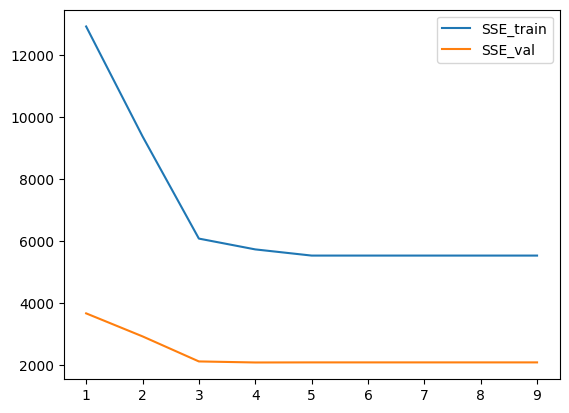

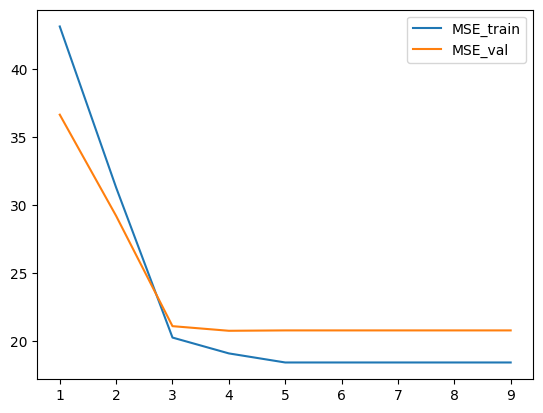

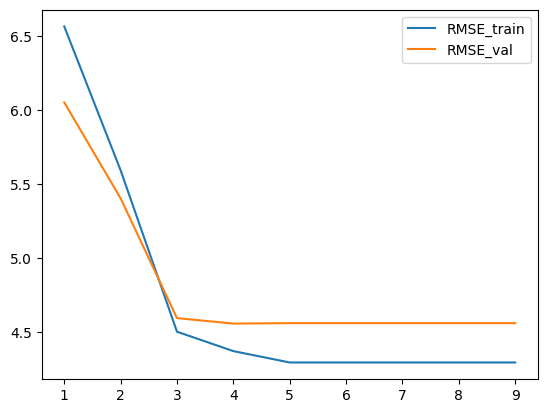

In [168]:
iters = range(1, len(features) + 5)

plt.plot(iters, SSE_train, label="SSE_train")
plt.plot(iters, SSE_val, label="SSE_val")
plt.legend()
plt.show()
plt.plot(iters, MSE_train, label="MSE_train")
plt.plot(iters, MSE_val, label="MSE_val")
plt.legend()
plt.show()
plt.plot(iters, RMSE_train, label="RMSE_train")
plt.plot(iters, RMSE_val, label="RMSE_val")
plt.legend()
plt.show()

#### Шаг 6. Применение модели на тестовой выборке

In [169]:
model = Ridge(alpha=0, solver='sparse_cg')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#### Шаг 7. RMSE на тестовой выборке

In [170]:
SSE = ((y_pred - y_test) ** 2).sum()
MSE = SSE / len(y_pred)
RMSE = np.sqrt(MSE)

RMSE # попробовал Ridge с alpha=1, RMSE не изменился, регуляризация на этих данных не нужна

np.float64(4.831131903177555)

In [171]:
help(Ridge)

Help on class Ridge in module sklearn.linear_model._ridge:

class Ridge(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, _BaseRidge)
 |  Ridge(
 |      alpha=1.0,
 |      *,
 |      fit_intercept=True,
 |      copy_X=True,
 |      max_iter=None,
 |      tol=0.0001,
 |      solver='auto',
 |      positive=False,
 |      random_state=None
 |  )
 |
 |  Linear least squares with l2 regularization.
 |
 |  Minimizes the objective function::
 |
 |  ||y - Xw||^2_2 + alpha * ||w||^2_2
 |
 |  This model solves a regression model where the loss function is
 |  the linear least squares function and regularization is given by
 |  the l2-norm. Also known as Ridge Regression or Tikhonov regularization.
 |  This estimator has built-in support for multi-variate regression
 |  (i.e., when y is a 2d-array of shape (n_samples, n_targets)).
 |
 |  Read more in the :ref:`User Guide <ridge_regression>`.
 |
 |  Parameters
 |  ----------
 |  alpha : {float, ndarray of shape (n_targets,)}, default=1.